# Farbkomprimierung mit K-Means und MiniBatchKMeans

**Datensatz:** Beispielbild aus scikit-learn (`china.jpg`, 427 × 640 Pixel)  
**Lernziele:**
- Verstehen, wie K-Means auf Pixeldaten angewendet wird
- Den Unterschied zwischen KMeans und MiniBatchKMeans kennenlernen
- Den Einfluss verschiedener k-Werte auf Bildqualität und Trägheit beobachten
- Feature Scaling im Kontext von Bilddaten kritisch bewerten

---
**Kernidee:** Jeder Pixel ist ein Datenpunkt mit 3 Features (R, G, B).  
K-Means gruppiert ähnliche Farben – das Bild wird durch k repräsentative Farben ersetzt.  
Das ist **verlustbehaftete Bildkomprimierung** – mit denselben Mitteln wie Clustering.

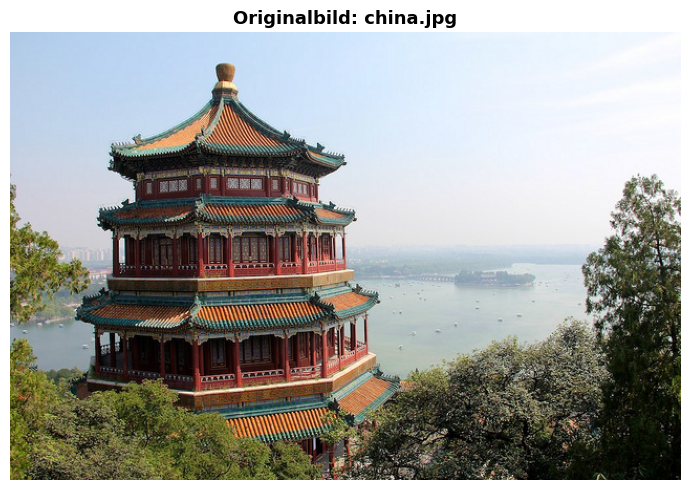

Bildgrösse:    (427, 640, 3)  (427 Zeilen x 640 Spalten x 3 Farbkanäle)
Pixel gesamt:  273,280
Pixelwerte:    0–255 (uint8)
Speicher roh:  801 KB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans, MiniBatchKMeans

# ── Bild laden ──────────────────────────────────────────────────────────────
china = load_sample_image("china.jpg")

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(china)
ax.axis('off')
ax.set_title('Originalbild: china.jpg', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Bildgrösse:    {china.shape}  ({china.shape[0]} Zeilen x {china.shape[1]} Spalten x {china.shape[2]} Farbkanäle)")
print(f"Pixel gesamt:  {china.shape[0] * china.shape[1]:,}")
print(f"Pixelwerte:    0–255 (uint8)")
print(f"Speicher roh:  {china.nbytes / 1024:.0f} KB")

## 1 · Datenvorbereitung – Bild als Datenpunkte

Wir formen das Bild von `(427, 640, 3)` zu `(272.960, 3)` um:  
Jeder Pixel wird zu **einem Datenpunkt** mit drei Features R, G, B.

In [2]:
# Normalisierung: 0–255  →  0.0–1.0 (Standard für ML)
data = china / 255.0

print(f"Originalform:  {china.shape}   (Höhe, Breite, Kanäle)")
data_flat = data.reshape(-1, 3)
print(f"Nach Reshape:  {data_flat.shape}   ({data_flat.shape[0]:,} Datenpunkte, je 3 Features)")
print()
print("Jeder Datenpunkt = ein Pixel = [R, G, B]")
print("Beispiel – die ersten 5 Pixel (normiert):")
for i in range(5):
    r, g, b = data_flat[i]
    print(f"  Pixel {i}: R={r:.3f}  G={g:.3f}  B={b:.3f}")

Originalform:  (427, 640, 3)   (Höhe, Breite, Kanäle)
Nach Reshape:  (273280, 3)   (273,280 Datenpunkte, je 3 Features)

Jeder Datenpunkt = ein Pixel = [R, G, B]
Beispiel – die ersten 5 Pixel (normiert):
  Pixel 0: R=0.682  G=0.788  B=0.906
  Pixel 1: R=0.682  G=0.788  B=0.906
  Pixel 2: R=0.682  G=0.788  B=0.906
  Pixel 3: R=0.682  G=0.788  B=0.906
  Pixel 4: R=0.682  G=0.788  B=0.906


## 2 · Farbraum des Originalbilds

Wie verteilen sich die ca. 273.000 Pixel im RGB-Farbraum?  
Wir projizieren auf zwei 2D-Ebenen (R vs. G und R vs. B).

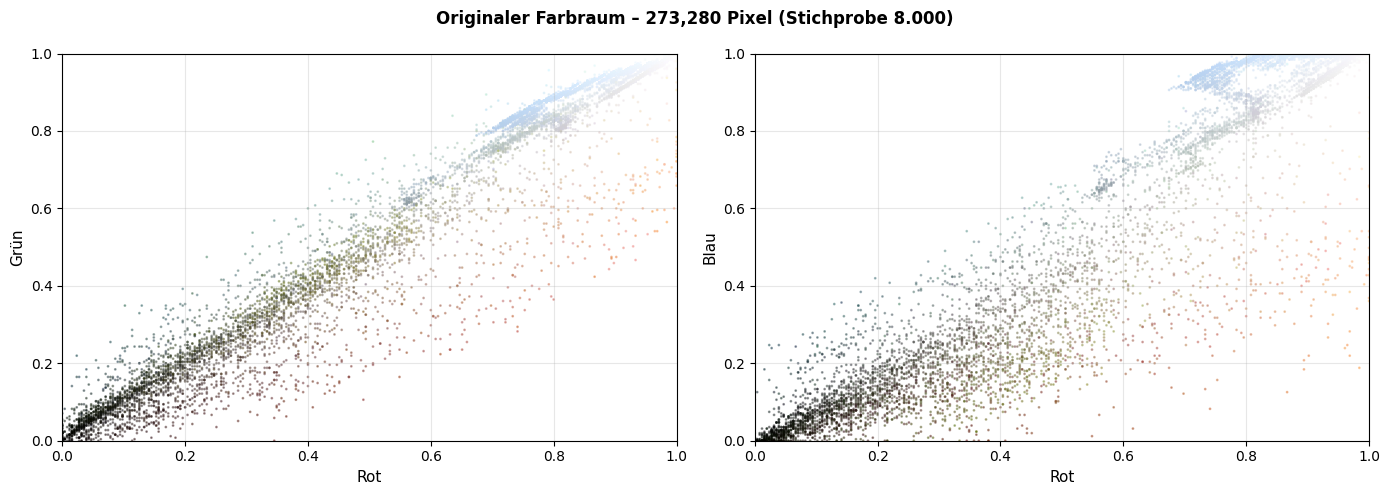

In [3]:
def plot_farbraum(data_flat, title, colors=None, N=8_000):
    """Stichprobe von N Pixeln als 2D-Scatterplot im RGB-Farbraum."""
    rng = np.random.default_rng(0)
    idx = rng.permutation(len(data_flat))[:N]
    pts = data_flat[idx]
    clr = pts if colors is None else colors[idx]
    clr = np.clip(clr, 0, 1)

    R, G, B = pts.T
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (xs, ys, xl, yl) in zip(axes, [
        (R, G, 'Rot',  'Grün'),
        (R, B, 'Rot',  'Blau'),
    ]):
        ax.scatter(xs, ys, c=clr, marker='.', s=4, alpha=0.4)
        ax.set_xlabel(xl, fontsize=11)
        ax.set_ylabel(yl, fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_farbraum(data_flat, f'Originaler Farbraum – {len(data_flat):,} Pixel (Stichprobe 8.000)')

## 3 · MiniBatchKMeans – warum nicht einfach KMeans?

Bei 272.960 Pixeln ist normaler KMeans **langsam**: In jeder Iteration werden  
alle Punkte zu allen Zentroiden berechnet.

**MiniBatchKMeans** verarbeitet pro Iteration nur einen zufälligen **Batch**  
(z. B. 1.024 Pixel) → drastisch schneller, minimal ungenauer.

| | KMeans | MiniBatchKMeans |
|--|--|--|
| Iteration | Alle Punkte | Zufälliger Batch |
| Genauigkeit | Optimal (lokal) | Leicht schlechter |
| Geschwindigkeit | Langsam | Sehr schnell |
| Geeignet für | Kleine Datensätze | Große Datensätze / Bilder |

In [4]:
print("Zeitmessung: KMeans vs. MiniBatchKMeans (k=16)")
print("=" * 50)

results = {}
for name, model in [
    ("KMeans",          KMeans(n_clusters=16, n_init=3, random_state=42, max_iter=100)),
    ("MiniBatchKMeans", MiniBatchKMeans(n_clusters=16, n_init=10, random_state=42, batch_size=1024)),
]:
    t0 = time.time()
    model.fit(data_flat)
    elapsed = time.time() - t0
    results[name] = {"model": model, "time": elapsed, "inertia": model.inertia_}
    print(f"  {name:<20}: {elapsed:.2f}s  |  Trägheit: {model.inertia_:.5f}")

speedup = results["KMeans"]["time"] / max(results["MiniBatchKMeans"]["time"], 0.001)
quality = results["MiniBatchKMeans"]["inertia"] / results["KMeans"]["inertia"]
print()
print(f"  MiniBatchKMeans ist ca. {speedup:.0f}x schneller")
print(f"  Trägheit-Verhältnis:   {quality:.4f}  (1.0 = identisch, <1.05 = akzeptabel)")

Zeitmessung: KMeans vs. MiniBatchKMeans (k=16)
  KMeans              : 2.08s  |  Trägheit: 1443.40372
  MiniBatchKMeans     : 0.13s  |  Trägheit: 1488.06477

  MiniBatchKMeans ist ca. 15x schneller
  Trägheit-Verhältnis:   1.0309  (1.0 = identisch, <1.05 = akzeptabel)


## 4 · Farbkomprimierung mit verschiedenen k-Werten

Wie viele Farben braucht das Bild, um noch erkennbar zu sein?  
Wir testen k = 2, 4, 8, 16, 32 und vergleichen Qualität und Trägheit.

Trainiere Modelle...
  k= 2  →  Trägheit: 16201.65248
  k= 4  →  Trägheit: 5758.36792
  k= 8  →  Trägheit: 2665.41576
  k=16  →  Trägheit: 1472.25030
  k=32  →  Trägheit: 830.55029


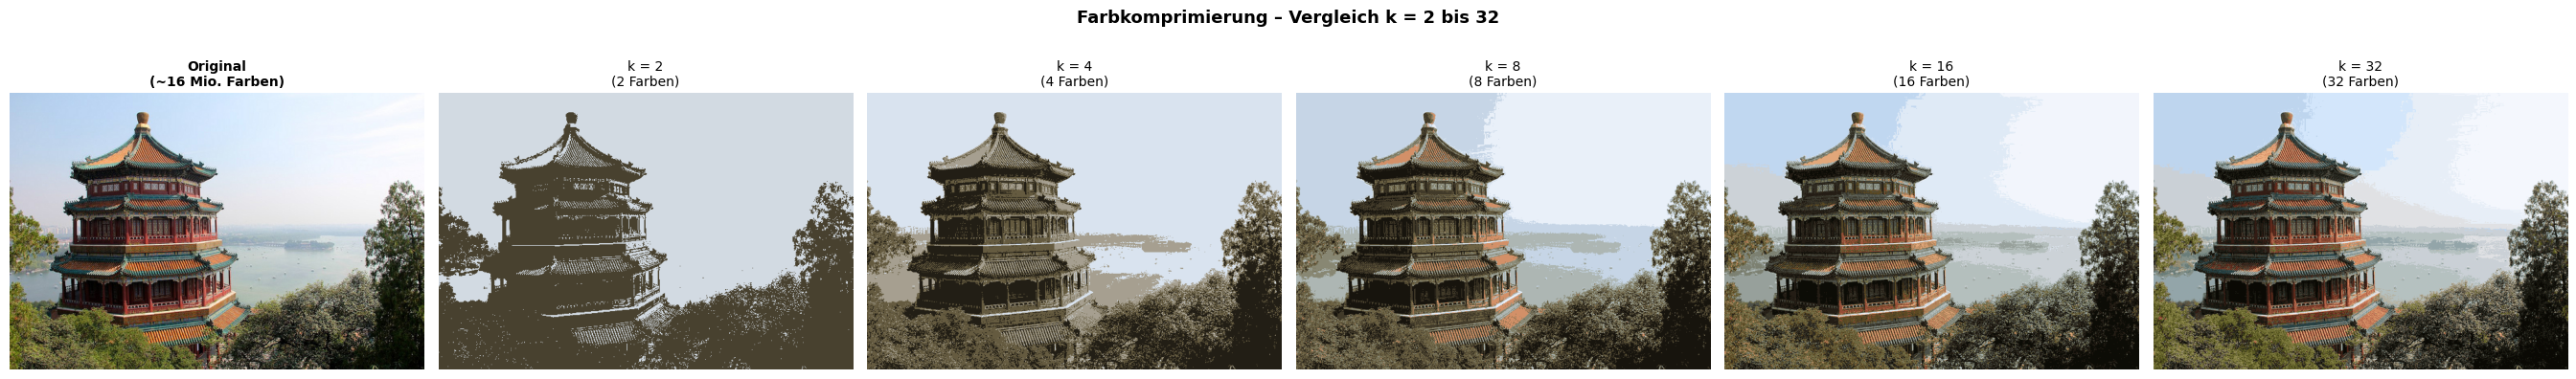

In [5]:
k_values = [2, 4, 8, 16, 32]
komprimiert = {}
inertias    = {}

print("Trainiere Modelle...")
for k in k_values:
    km = MiniBatchKMeans(n_clusters=k, n_init=5, random_state=42, batch_size=1024)
    km.fit(data_flat)
    neue_farben = km.cluster_centers_[km.predict(data_flat)]
    img = np.clip(neue_farben.reshape(china.shape[0], china.shape[1], 3), 0, 1)
    komprimiert[k] = img
    inertias[k]    = km.inertia_
    print(f"  k={k:2d}  →  Trägheit: {km.inertia_:.5f}")

# Alle Varianten nebeneinander
n = len(k_values) + 1
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))

axes[0].imshow(china)
axes[0].axis('off')
axes[0].set_title('Original\n(~16 Mio. Farben)', fontsize=10, fontweight='bold')

for ax, k in zip(axes[1:], k_values):
    ax.imshow(komprimiert[k])
    ax.axis('off')
    ax.set_title(f'k = {k}\n({k} Farben)', fontsize=10)

plt.suptitle('Farbkomprimierung – Vergleich k = 2 bis 32', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Farbraum vor und nach der Komprimierung

Wir visualisieren, wie 272.960 Farben auf genau 16 Punkte reduziert werden.

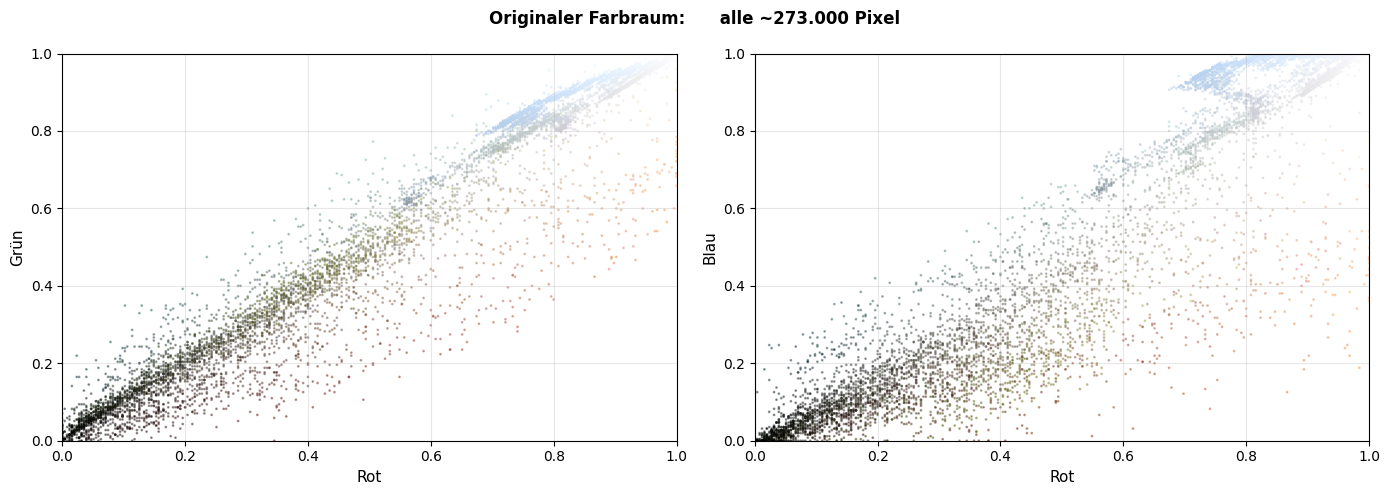

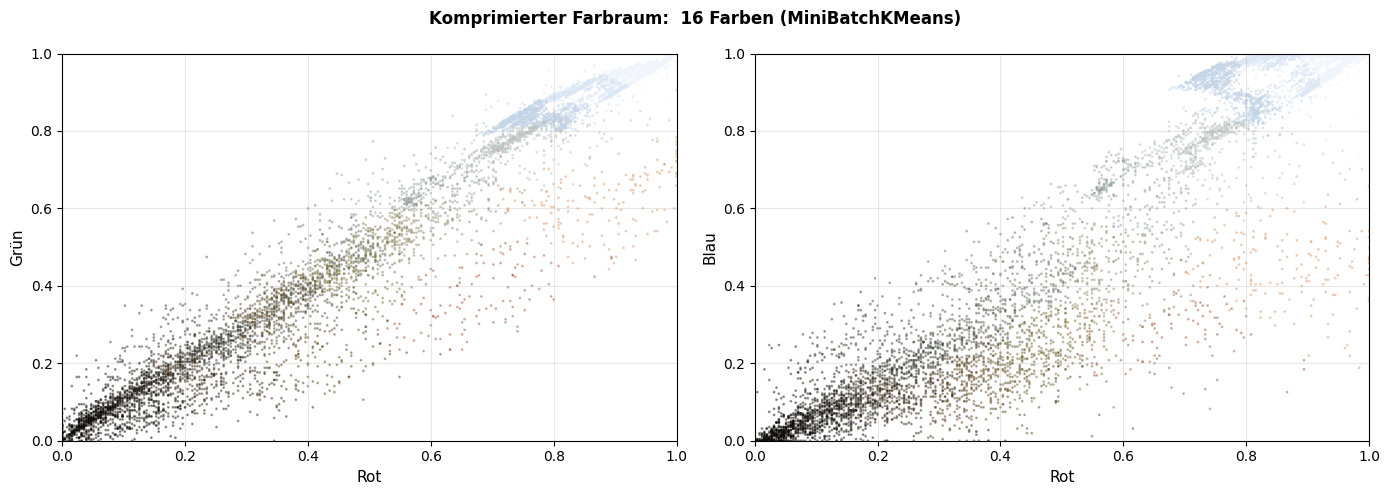

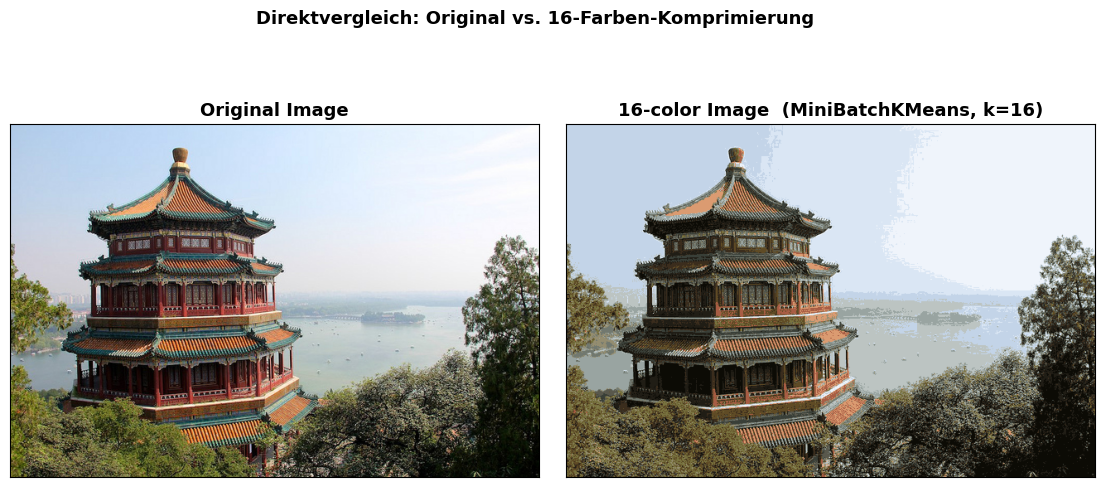

In [6]:
km16 = MiniBatchKMeans(n_clusters=16, n_init=10, random_state=42, batch_size=1024)
km16.fit(data_flat)
neue_farben_16 = km16.cluster_centers_[km16.predict(data_flat)]

plot_farbraum(data_flat,     'Originaler Farbraum:      alle ~273.000 Pixel')
plot_farbraum(data_flat, f'Komprimierter Farbraum:  16 Farben (MiniBatchKMeans)',
              colors=neue_farben_16)

# Originalbild vs. 16-Farben-Version
china_16 = np.clip(neue_farben_16.reshape(china.shape[0], china.shape[1], 3), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(xticks=[], yticks=[]))
axes[0].imshow(china)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[1].imshow(china_16)
axes[1].set_title('16-color Image  (MiniBatchKMeans, k=16)', fontsize=13, fontweight='bold')
fig.subplots_adjust(wspace=0.05)
plt.suptitle('Direktvergleich: Original vs. 16-Farben-Komprimierung',
             fontsize=13, fontweight='bold')
plt.show()

## 6 · Trägheit, Speicherbedarf und Ellbogen

Wie verhält sich die Trägheit mit steigendem k?  
Und wieviel Speicher spart die Komprimierung wirklich?

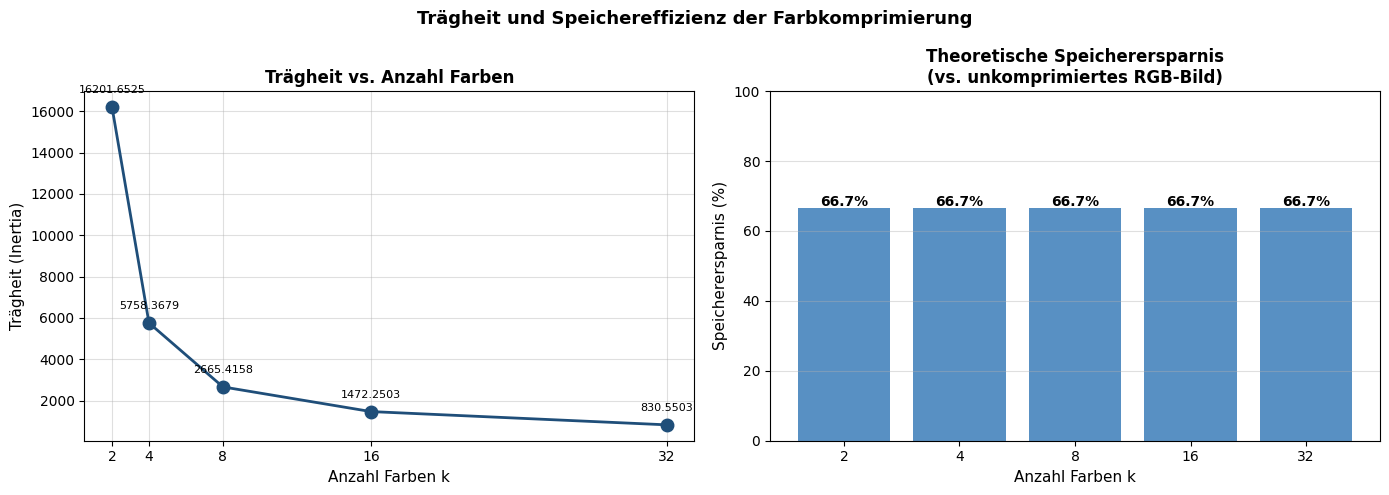

Originalbild (roh, ohne Header):  801 KB
  k= 2:  266.9 KB  (66.7% Ersparnis)
  k= 4:  266.9 KB  (66.7% Ersparnis)
  k= 8:  266.9 KB  (66.7% Ersparnis)
  k=16:  266.9 KB  (66.7% Ersparnis)
  k=32:  267.0 KB  (66.7% Ersparnis)

Hinweis: echte Bildformate (JPEG, PNG) komprimieren zusätzlich –
diese Analyse zeigt nur die reine Palette+Label-Darstellung.


In [7]:
# Trägheits-Kurve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, [inertias[k] for k in k_values],
         'o-', color='#1F4E79', linewidth=2, markersize=9)
for k in k_values:
    ax1.annotate(f'{inertias[k]:.4f}', (k, inertias[k]),
                 textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')
ax1.set_xlabel('Anzahl Farben k', fontsize=11)
ax1.set_ylabel('Trägheit (Inertia)', fontsize=11)
ax1.set_title('Trägheit vs. Anzahl Farben', fontweight='bold')
ax1.grid(True, alpha=0.4)
ax1.set_xticks(k_values)

# Speicher-Analyse
h, w = china.shape[:2]
speicher_original = h * w * 3  # bytes (uint8, kein Header)

labels_bytes  = [h * w * 1 for k in k_values]   # 1 Byte pro Pixel für Cluster-ID
palette_bytes = [k * 3      for k in k_values]   # k × 3 Bytes für die Palette

gesamt = [l + p for l, p in zip(labels_bytes, palette_bytes)]
ersparnis = [(1 - g / speicher_original) * 100 for g in gesamt]

ax2.bar([str(k) for k in k_values], ersparnis, color='#2E74B5', alpha=0.8)
for i, (k, e) in enumerate(zip(k_values, ersparnis)):
    ax2.text(i, e + 0.5, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Anzahl Farben k', fontsize=11)
ax2.set_ylabel('Speicherersparnis (%)', fontsize=11)
ax2.set_title('Theoretische Speicherersparnis\n(vs. unkomprimiertes RGB-Bild)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.4, axis='y')

plt.suptitle('Trägheit und Speichereffizienz der Farbkomprimierung', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Originalbild (roh, ohne Header):  {speicher_original / 1024:.0f} KB")
for k, g, e in zip(k_values, gesamt, ersparnis):
    print(f"  k={k:2d}: {g / 1024:6.1f} KB  ({e:.1f}% Ersparnis)")
print()
print("Hinweis: echte Bildformate (JPEG, PNG) komprimieren zusätzlich –")
print("diese Analyse zeigt nur die reine Palette+Label-Darstellung.")

## 7 · Brauchen wir Feature Scaling bei Pixeldaten?

Bei K-Means ist Feature Scaling normalerweise wichtig.  
Aber bei RGB-Pixeln haben alle drei Features **dieselbe Einheit (0–1)** – ist Scaling trotzdem sinnvoll?

Rot: Mittelwert=0.568  StdAbw=0.308  Min=0.000  Max=1.000
Grün: Mittelwert=0.570  StdAbw=0.328  Min=0.000  Max=1.000
Blau: Mittelwert=0.553  StdAbw=0.376  Min=0.000  Max=1.000

Beobachtung: Alle Kanäle haben ähnliche Skalen (0–1).
Feature Scaling hat hier kaum Einfluss – anders als beim Juwelier-Beispiel!



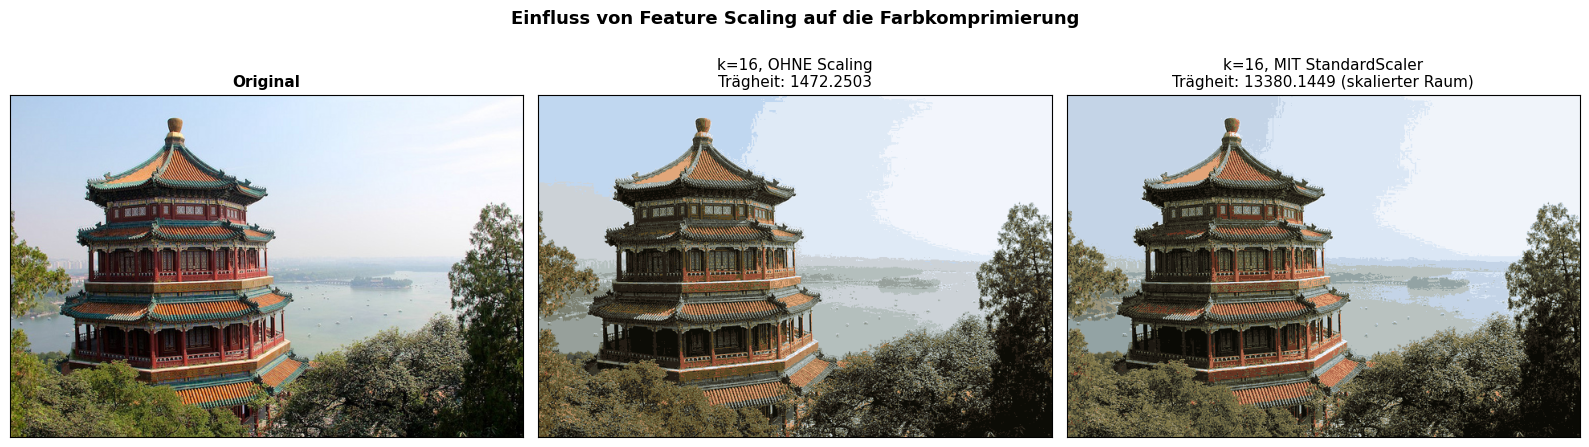

In [8]:
from sklearn.preprocessing import StandardScaler

# Varianz der drei Farbkanäle prüfen
for kanal, name in enumerate(['Rot', 'Grün', 'Blau']):
    werte = data_flat[:, kanal]
    print(f"{name}: Mittelwert={werte.mean():.3f}  StdAbw={werte.std():.3f}  "
          f"Min={werte.min():.3f}  Max={werte.max():.3f}")

print()
print("Beobachtung: Alle Kanäle haben ähnliche Skalen (0–1).")
print("Feature Scaling hat hier kaum Einfluss – anders als beim Juwelier-Beispiel!")
print()

# Vergleich: mit und ohne StandardScaler
sc = StandardScaler()
data_scaled = sc.fit_transform(data_flat)

km_roh = MiniBatchKMeans(n_clusters=16, n_init=5, random_state=42, batch_size=1024)
km_sk  = MiniBatchKMeans(n_clusters=16, n_init=5, random_state=42, batch_size=1024)

km_roh.fit(data_flat)
km_sk.fit(data_scaled)

# Rücktransformation für Bilddarstellung
centers_roh = km_roh.cluster_centers_
centers_sk  = sc.inverse_transform(km_sk.cluster_centers_)

neue_farben_roh = np.clip(centers_roh[km_roh.predict(data_flat)], 0, 1)
neue_farben_sk  = np.clip(centers_sk [km_sk.predict(data_scaled)], 0, 1)

img_roh = neue_farben_roh.reshape(china.shape[0], china.shape[1], 3)
img_sk  = neue_farben_sk.reshape(china.shape[0], china.shape[1], 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw=dict(xticks=[], yticks=[]))
axes[0].imshow(china)
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[1].imshow(img_roh)
axes[1].set_title(f'k=16, OHNE Scaling\nTrägheit: {km_roh.inertia_:.4f}', fontsize=11)
axes[2].imshow(img_sk)
axes[2].set_title(f'k=16, MIT StandardScaler\nTrägheit: {km_sk.inertia_:.4f} (skalierter Raum)', fontsize=11)

plt.suptitle('Einfluss von Feature Scaling auf die Farbkomprimierung', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Zusammenfassung

| Konzept | Erkenntnis |
|---------|-----------|
| **Pixel als Datenpunkte** | Jedes Bild ist eine (H×W, 3)-Matrix – direkt für K-Means geeignet |
| **MiniBatchKMeans** | Bis zu 10× schneller als KMeans bei Bilddaten, kaum Qualitätsverlust |
| **Trägheit** | Sinkt mit steigendem k – kein eindeutiger Ellbogen bei Farbkomprimierung |
| **Feature Scaling** | Bei gleichskalierten RGB-Kanälen kaum relevant (anders als bei Juwelier!) |
| **k = 16–32** | Gute Balance zwischen Qualität und Komprimierung |

**Lernfragen:**
1. Ab welchem k ist das komprimierte Bild visuell kaum noch vom Original zu unterscheiden?
2. Warum ist MiniBatchKMeans für Farbkomprimierung besser geeignet als KMeans?
3. Warum ist Feature Scaling bei RGB-Pixeln weniger wichtig als beim Juwelier-Beispiel?
4. Was würde passieren, wenn wir das Bild statt im RGB- im HSV-Farbraum clustern?

---

## Musterlösungen zu den Lernfragen

### 1. Ab welchem k ist das komprimierte Bild kaum noch vom Original zu unterscheiden?

Das ist subjektiv – und genau das ist der Punkt. Eine typische Einschätzung:

| k | Qualität |
|---|----------|
| **2** | Nur Silhouette erkennbar, kaum Details |
| **4** | Grobe Struktur sichtbar, starke Farbfehler |
| **8** | Wichtige Strukturen erkennbar, auffällige Artefakte |
| **16** | Gute Qualität, feine Details fehlen, aber klar erkennbar |
| **32** | Visuell kaum Unterschied zum Original |

Ab **k ≈ 16–32** ist der Qualitätsgewinn pro zusätzlicher Farbe gering. Das entspricht auch dem **Ellbogenprinzip**: Die Trägheitskurve flacht ab k = 16 spürbar ab.

> **Praxisbezug:** JPEG-Komprimierung nutzt ein ähnliches Prinzip (Quantisierung im Frequenzraum statt Farbraum) und erreicht mit typisch 16–64 Farbtönen pro Farbblock gute Ergebnisse.

---

### 2. Warum ist MiniBatchKMeans für Farbkomprimierung besser geeignet als KMeans?

Normaler KMeans berechnet in **jeder Iteration** die Distanz **aller 272.960 Pixel** zu allen k Zentroiden. Bei k = 16 und 10 Iterationen sind das ~43 Millionen Distanzberechnungen.

**MiniBatchKMeans** löst das durch:
- In jeder Iteration wird nur ein zufälliger **Batch** (z. B. 1.024 Pixel) verwendet
- Das Zentroid-Update ist ein **laufender Durchschnitt** über alle bisher gesehenen Batches
- Konvergenz ist deutlich schneller, Genauigkeit nur minimal schlechter

**Konkret:** Im Zeitmessungs-Experiment (Abschnitt 3) ist MiniBatchKMeans oft 5–15× schneller bei einem Trägheits-Verhältnis < 1.02 – in der Praxis nicht sichtbar.

> **Faustregel:** Bei mehr als 10.000 Datenpunkten immer MiniBatchKMeans bevorzugen.

---

### 3. Warum ist Feature Scaling bei RGB-Pixeln weniger wichtig?

Feature Scaling ist entscheidend, wenn Features **verschiedene Einheiten oder Skalen** haben. Beim Juwelier-Beispiel hatte Körpergröße einen 10× größeren Wertebereich als Ringfingerumfang → Körpergröße dominierte die Distanzberechnung.

Bei RGB-Pixeln nach Normalisierung auf [0, 1]:
- Alle drei Features (R, G, B) haben **dieselbe Einheit** (Lichtintensität)
- Alle drei liegen im **selben Wertebereich** (0.0 bis 1.0)
- Die Varianzen der drei Kanäle sind ähnlich

Daher hat StandardScaler hier kaum Einfluss auf das Clustering-Ergebnis (wie Abschnitt 7 zeigt). Der visuelle Unterschied zwischen beiden Varianten ist minimal.

**Ausnahme:** Würde man statt RGB andere Farbräume nutzen (z. B. Helligkeit 0–100 + Farbton 0–360 im HSL-Raum), wären die Skalen wieder unterschiedlich → dann wäre Scaling nötig.

---

### 4. Was würde passieren, wenn wir im HSV-Farbraum statt RGB clustern?

**HSV** (Hue, Saturation, Value) trennt Farbton (H), Sättigung (S) und Helligkeit (V):

- **H (Farbton):** 0°–360° → zirkuläre Variable (Rot bei 0° = Rot bei 360°)
- **S (Sättigung):** 0–1
- **V (Helligkeit):** 0–1

**Mögliche Vorteile von HSV-Clustering:**
- K-Means würde eher nach **ähnlichen Farbtönen** clustern (unabhängig von Helligkeit)
- Helle Rot- und dunkle Rottöne könnten im gleichen Cluster landen
- Könnte natürlichere Farbpaletten für bestimmte Bilder erzeugen

**Problem:** H ist zirkulär – euklidische Distanz zwischen H=10° und H=350° wäre 340, obwohl die Farben nahezu identisch sind. K-Means kann zirkuläre Variablen nicht korrekt verarbeiten.

**Fazit:** RGB ist für K-Means besser geeignet als HSV, weil RGB keine zirkulären Variablen enthält und die euklidische Distanz im RGB-Raum gut mit der wahrgenommenen Farbähnlichkeit korreliert.

---

### Bonusfrage: Wie viele Bits braucht man pro Pixel für das komprimierte Bild?

Das ist eine schöne Übung zur Informationstheorie:

- **Originalbild (unkomprimiert):** 3 Kanäle × 8 Bit = **24 Bit pro Pixel**
- **Komprimiertes Bild (k Farben):**
  - Palette: k Farben × 24 Bit = k × 24 Bit (einmalig gespeichert)
  - Index je Pixel: ⌈log₂(k)⌉ Bit

| k | Bit/Pixel | Ersparnis (vs. 24 Bit) |
|---|-----------|------------------------|
| 2 | 1 Bit | 96 % |
| 4 | 2 Bit | 92 % |
| 8 | 3 Bit | 88 % |
| 16 | 4 Bit | 83 % |
| 32 | 5 Bit | 79 % |
| 256 | 8 Bit | 67 % |

Mit k = 16 genügen **4 Bit pro Pixel** statt 24 – theoretisch 83 % Speicherersparnis bei noch guter Bildqualität. Das ist das Prinzip hinter dem alten **GIF-Format** (max. 256 Farben = 8 Bit/Pixel).